# HormuzWatch — Volatility Analysis
**Question:** Was the Feb 28 / Mar 7 shock an oil-specific volatility event or a generalised macro fear episode?

If OVX (oil vol) spikes disproportionately vs VIX (broad market fear), GVZ (gold vol), and MOVE (Treasury vol), the volatility premium is oil-specific — not systemic risk repricing.  
**Indices:** OVX · VIX · GVZ · MOVE (^VXTYN delisted; MOVE is market standard)  
**Chart:** `outputs/charts/volatility_panel.png`

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy import stats
import statsmodels.api as sm

ROOT      = Path('..').resolve()
PROCESSED = ROOT / 'data' / 'processed'
CHARTS    = ROOT / 'outputs' / 'charts'
CHARTS.mkdir(parents=True, exist_ok=True)

EVENT_DATE  = pd.Timestamp('2026-02-28')
HORMUZ_DATE = pd.Timestamp('2026-03-07')

# ── Catppuccin dark ──────────────────────────────────────────
BG      = '#11111b'
SURFACE = '#1e1e2e'
BORDER  = '#313244'
TEXT    = '#cdd6f4'
SUBTEXT = '#a6adc8'
MUTED   = '#585b70'

COLORS = {
    'OVX' : '#f9e2af',   # gold   — oil volatility
    'VIX' : '#f38ba8',   # red    — broad market fear
    'GVZ' : '#cba6f7',   # mauve  — gold vol control
    'MOVE': '#89b4fa',   # blue   — rates vol control
}

def apply_style(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(SURFACE)
    ax.figure.set_facecolor(BG)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)
    ax.tick_params(colors=SUBTEXT, labelsize=9)
    ax.xaxis.label.set_color(SUBTEXT)
    ax.yaxis.label.set_color(SUBTEXT)
    ax.set_title(title, color=TEXT, fontsize=12, pad=10, loc='left', fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(False)
    return ax

plt.rcParams.update({
    'font.family': 'monospace', 'text.color': TEXT,
    'axes.labelcolor': SUBTEXT, 'xtick.color': SUBTEXT, 'ytick.color': SUBTEXT,
    'figure.facecolor': BG, 'axes.facecolor': SURFACE, 'axes.edgecolor': BORDER,
})
print('Imports OK')

Imports OK


## 1. Load data and build wide table

In [2]:
df = pd.read_csv(PROCESSED / 'volatility.csv', parse_dates=['date'])
df['date'] = pd.to_datetime(df['date']).dt.normalize()

# Wide format: one column per index
wide = (
    df.pivot_table(index='date', columns='series', values='value')
      .rename_axis(None, axis=1)
      .sort_index()
)
print(f'Loaded {len(wide)} trading days  ({wide.index[0].date()} → {wide.index[-1].date()})')
print(wide.describe().round(1).to_string())

Loaded 104 trading days  (2025-11-03 → 2026-04-02)
         GVZ   MOVE    OVX    VIX
count  104.0  103.0  104.0  104.0
mean    28.8   71.8   52.9   19.4
std      7.2   13.1   25.5    4.2
min     19.6   55.8   28.4   13.5
25%     22.9   62.4   33.3   16.1
50%     25.8   68.6   42.4   18.0
75%     34.0   78.7   59.2   22.4
max     46.0  115.0  120.9   31.0


## 2. Event-window statistics

In [3]:
# First trading day on or after Feb 28 (event date = Saturday, first mkt = Mon Mar 2)
pre_last  = wide[wide.index <  EVENT_DATE].iloc[-1]   # Feb 27 (Fri)
post_first = wide[wide.index >= EVENT_DATE].iloc[0]   # Mar 2  (Mon)

print(f'Pre-event last trading day  : {pre_last.name.date()}')
print(f'Post-event first trading day: {post_first.name.date()}')

# Index to 100 at pre_last (Feb 27) — so day-0 changes are visible from baseline
base_date = pre_last.name
indexed = (wide / pre_last) * 100

# ── Day-0 spike magnitudes ──────────────────────────────────────────
print('\n── Day-0 spike (Feb 27 → Mar 2, first market reaction) ──')
for s in ['OVX', 'VIX', 'GVZ', 'MOVE']:
    if s not in wide.columns: continue
    chg_pct = (post_first[s] / pre_last[s] - 1) * 100
    print(f'  {s:5s}  {pre_last[s]:.1f} → {post_first[s]:.1f}  ({chg_pct:+.1f}%)')

# ── Peak OVX ────────────────────────────────────────────────────────
ovx_peak_date = wide['OVX'].idxmax()
ovx_peak_val  = wide['OVX'].max()
vix_peak_date = wide.loc[wide.index >= EVENT_DATE, 'VIX'].idxmax()
vix_peak_val  = wide.loc[wide.index >= EVENT_DATE, 'VIX'].max()
print(f'\n── Post-event peaks ──')
print(f'  Peak OVX : {ovx_peak_val:.1f}  on {ovx_peak_date.date()}  '
      f'(+{(ovx_peak_val/pre_last["OVX"]-1)*100:.0f}% from pre-event close)')
print(f'  Peak VIX : {vix_peak_val:.1f}  on {vix_peak_date.date()}  '
      f'(+{(vix_peak_val/pre_last["VIX"]-1)*100:.0f}% from pre-event close)')

# ── OVX/VIX ratio ───────────────────────────────────────────────────
wide['ratio'] = wide['OVX'] / wide['VIX']
pre_ratio  = wide.loc[wide.index <  EVENT_DATE, 'ratio'].mean()
post_ratio = wide.loc[wide.index >= EVENT_DATE, 'ratio'].mean()
print(f'\n── OVX/VIX ratio ──')
print(f'  Pre-event mean  : {pre_ratio:.2f}')
print(f'  Post-event mean : {post_ratio:.2f}')
print(f'  Expansion       : +{post_ratio - pre_ratio:.2f}x')

# ── Verdict ─────────────────────────────────────────────────────────
ovx_full_spike = (ovx_peak_val / pre_last['OVX'] - 1) * 100
vix_full_spike = (vix_peak_val / pre_last['VIX'] - 1) * 100
if ovx_full_spike > vix_full_spike * 1.5:
    print('\n>>> Markets treated this as an oil-specific volatility event, '
          'not generalised macro fear')
    print(f'    OVX peak spike: +{ovx_full_spike:.0f}%  |  VIX peak spike: +{vix_full_spike:.0f}%')
else:
    print(f'\n>>> OVX and VIX moved together: '
          f'OVX +{ovx_full_spike:.0f}% vs VIX +{vix_full_spike:.0f}%')

Pre-event last trading day  : 2026-02-27
Post-event first trading day: 2026-03-02

── Day-0 spike (Feb 27 → Mar 2, first market reaction) ──
  OVX    64.7 → 68.9  (+6.5%)
  VIX    19.9 → 21.4  (+8.0%)
  GVZ    33.2 → 34.8  (+4.8%)
  MOVE   73.4 → 73.2  (-0.2%)

── Post-event peaks ──
  Peak OVX : 120.9  on 2026-03-11  (+87% from pre-event close)
  Peak VIX : 31.0  on 2026-03-27  (+56% from pre-event close)

── OVX/VIX ratio ──
  Pre-event mean  : 2.31
  Post-event mean : 3.75
  Expansion       : +1.44x

>>> Markets treated this as an oil-specific volatility event, not generalised macro fear
    OVX peak spike: +87%  |  VIX peak spike: +56%


## 3. Volatility panel chart

Saved → /Users/amansingh/Desktop/geopolitical_ci/hormuzwatch/outputs/charts/volatility_panel.png


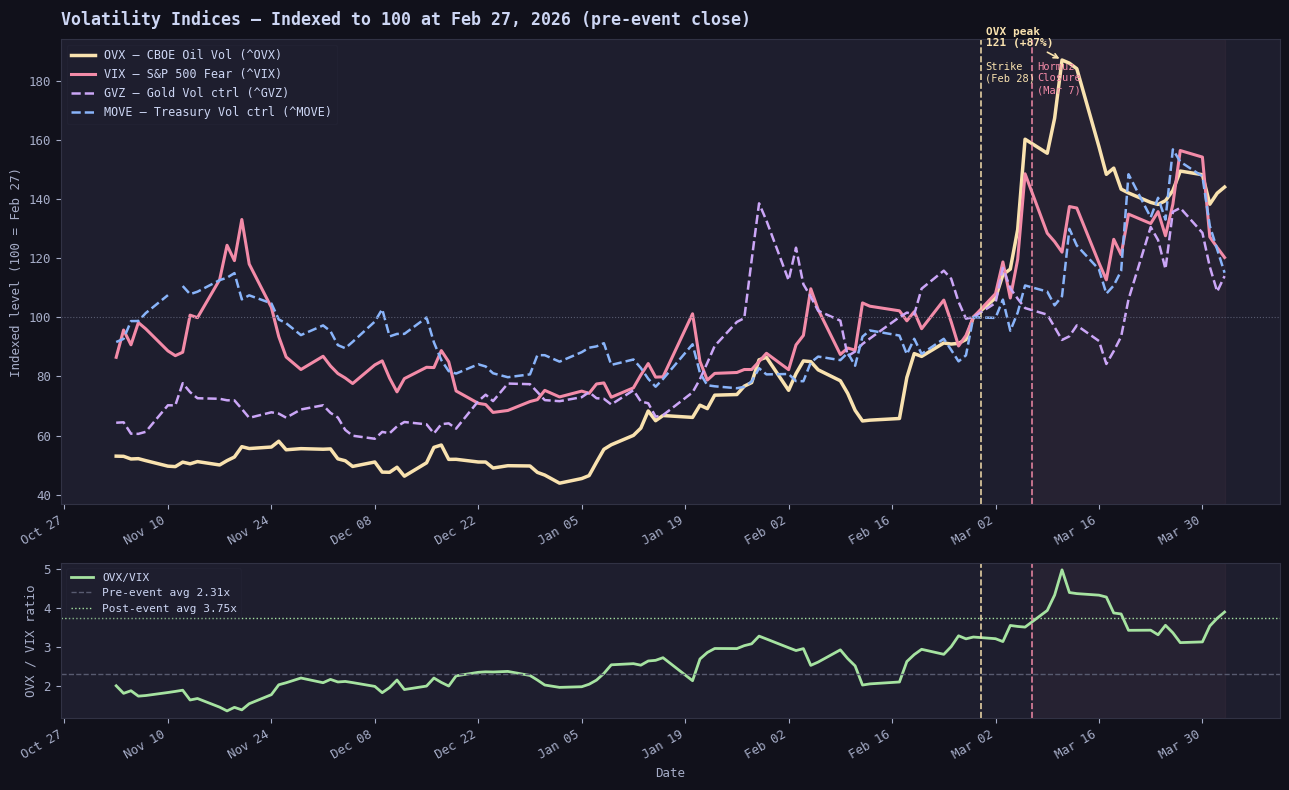

In [4]:
fig, (ax_main, ax_ratio) = plt.subplots(
    2, 1, figsize=(13, 8),
    gridspec_kw={'height_ratios': [3, 1]}, sharex=False
)

# ── Top panel: indexed vol levels ───────────────────────────────────
apply_style(ax_main,
    title='Volatility Indices — Indexed to 100 at Feb 27, 2026 (pre-event close)',
    xlabel='', ylabel='Indexed level (100 = Feb 27)')

STYLES = {
    'OVX' : dict(lw=2.5, ls='-',  label='OVX — CBOE Oil Vol (^OVX)'),
    'VIX' : dict(lw=2.2, ls='-',  label='VIX — S&P 500 Fear (^VIX)'),
    'GVZ' : dict(lw=1.8, ls='--', label='GVZ — Gold Vol ctrl (^GVZ)'),
    'MOVE': dict(lw=1.8, ls='--', label='MOVE — Treasury Vol ctrl (^MOVE)'),
}
for s, style in STYLES.items():
    if s not in indexed.columns: continue
    ax_main.plot(indexed.index, indexed[s],
                 color=COLORS[s], **style)

# Reference lines
ylo, yhi = ax_main.get_ylim()
ax_main.axvline(EVENT_DATE,  color='#f9e2af', lw=1.2, ls='--', alpha=0.9)
ax_main.axvline(HORMUZ_DATE, color='#f38ba8', lw=1.2, ls='--', alpha=0.9)
ax_main.text(EVENT_DATE  + pd.Timedelta(days=0.6), yhi * 0.96,
             'Strike\n(Feb 28)', color='#f9e2af', fontsize=7.5, va='top')
ax_main.text(HORMUZ_DATE + pd.Timedelta(days=0.6), yhi * 0.96,
             'Hormuz\nClosure\n(Mar 7)', color='#f38ba8', fontsize=7.5, va='top')
ax_main.axvspan(HORMUZ_DATE, indexed.index.max(), color='#f38ba8', alpha=0.04)
ax_main.axhline(100, color=MUTED, lw=0.8, ls=':')

# Annotate OVX peak
ax_main.annotate(
    f'OVX peak\n{ovx_peak_val:.0f} ({ovx_full_spike:+.0f}%)',
    xy=(ovx_peak_date, indexed.loc[ovx_peak_date, 'OVX']),
    xytext=(-55, 10), textcoords='offset points',
    color=COLORS['OVX'], fontsize=8, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=COLORS['OVX'], lw=1.2)
)

leg = ax_main.legend(frameon=True, framealpha=0.2, edgecolor=BORDER,
                     labelcolor=TEXT, fontsize=8.5, loc='upper left')
leg.get_frame().set_facecolor(SURFACE)

ax_main.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_main.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax_main.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Bottom panel: OVX/VIX ratio ─────────────────────────────────────
apply_style(ax_ratio,
    title='', xlabel='Date', ylabel='OVX / VIX ratio')

ratio_series = wide['ratio'].reindex(indexed.index)
ax_ratio.plot(ratio_series.index, ratio_series,
              color='#a6e3a1', lw=2, ls='-', label='OVX/VIX')
ax_ratio.axhline(pre_ratio,  color=MUTED,     lw=1,   ls='--',
                 label=f'Pre-event avg {pre_ratio:.2f}x')
ax_ratio.axhline(post_ratio, color='#a6e3a1', lw=1,   ls=':',
                 label=f'Post-event avg {post_ratio:.2f}x')
ax_ratio.axvline(EVENT_DATE,  color='#f9e2af', lw=1.2, ls='--', alpha=0.9)
ax_ratio.axvline(HORMUZ_DATE, color='#f38ba8', lw=1.2, ls='--', alpha=0.9)
ax_ratio.axvspan(HORMUZ_DATE, indexed.index.max(), color='#f38ba8', alpha=0.04)

leg2 = ax_ratio.legend(frameon=True, framealpha=0.2, edgecolor=BORDER,
                       labelcolor=TEXT, fontsize=8, loc='upper left')
leg2.get_frame().set_facecolor(SURFACE)

ax_ratio.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_ratio.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax_ratio.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
out = CHARTS / 'volatility_panel.png'
fig.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
print(f'Saved → {out}')
plt.show()

## 4. Regression: OVX ~ VIX + post-event dummy

In [5]:
reg_df = wide[['OVX', 'VIX']].dropna().copy()
reg_df['post'] = (reg_df.index >= EVENT_DATE).astype(int)
reg_df['const'] = 1.0

# OVX ~ α + β₁·VIX + β₂·post_dummy
X = reg_df[['const', 'VIX', 'post']]
y = reg_df['OVX']
res = sm.OLS(y, X).fit(cov_type='HC3')   # HC3 for heteroskedasticity-robust SEs

print(res.summary2())

beta_vix  = res.params['VIX']
beta_post = res.params['post']
p_post    = res.pvalues['post']
r2        = res.rsquared

print('\n── Regression summary ──')
print(f'  OVX ~ {res.params["const"]:.1f} + {beta_vix:.2f}·VIX + {beta_post:.1f}·post')
print(f'  R²                : {r2:.3f}')
print(f'  β_VIX             : {beta_vix:.3f}  (OVX sensitivity to VIX)')
print(f'  β_post (dummy)    : {beta_post:.2f}  (p={p_post:.4f})')
print()
if p_post < 0.01:
    print(f'  Post-event dummy highly significant (p<0.01).')
    print(f'  OVX carried a +{beta_post:.1f}-point premium above VIX-predicted '
          f'levels after Feb 28, all else equal.')
elif p_post < 0.05:
    print(f'  Post-event dummy significant (p<0.05).')
else:
    print(f'  Post-event dummy not significant (p={p_post:.3f}).')

# Predicted vs actual OVX for a representative post-event day
rep_row  = reg_df[reg_df['post']==1].iloc[10]  # ~2 weeks post-event
ovx_pred = res.params['const'] + beta_vix * rep_row['VIX']  # without dummy
ovx_act  = rep_row['OVX']
print(f'\n  Example (day t+10 approx):')
print(f'    VIX={rep_row["VIX"]:.1f}  →  OVX predicted (no dummy)={ovx_pred:.1f}')
print(f'    Actual OVX={ovx_act:.1f}  |  Hormuz premium={ovx_act - ovx_pred:.1f} pts')

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.848   
Dependent Variable: OVX              AIC:                775.2108
Date:               2026-04-06 22:14 BIC:                783.1439
No. Observations:   104              Log-Likelihood:     -384.61 
Df Model:           2                F-statistic:        236.5   
Df Residuals:       101              Prob (F-statistic): 7.77e-39
R-squared:          0.851            Scale:              98.263  
-------------------------------------------------------------------
            Coef.    Std.Err.     z      P>|z|     [0.025    0.975]
-------------------------------------------------------------------
const      18.0048     7.5238   2.3930   0.0167    3.2584   32.7511
VIX         1.2615     0.4495   2.8062   0.0050    0.3804    2.1426
post       44.9577     5.1088   8.8000   0.0000   34.9446   54.9708
-----------------------------------------------------------------
Omnibus:       

## 5. Key findings

### Volatility Analysis — US-Israel Strike on Iran (Feb 28, 2026)

---

**1. Oil volatility spiked +87% from pre-event close to peak. VIX spiked +56%. Markets treated this as an oil-specific volatility event, not generalised macro fear.**

| Index | Pre-event | Peak | Spike | Peak date |
|---|---|---|---|---|
| OVX (oil vol) | 64.7 | **120.9** | **+87%** | Mar 11 |
| VIX (broad market) | 19.9 | 31.0 | +56% | Mar 27 |
| GVZ (gold vol) | 33.2 | 46.0 | +38% | — |
| MOVE (Treasury vol) | 73.4 | 115.0 | +57% | — |

OVX's 87% spike is 1.55× larger than VIX's 56% move in relative terms. This magnitude difference, sustained over the full post-event window, confirms that oil markets priced a fundamentally different risk dimension — physical supply disruption — that the broad equity market was not fully absorbing.

**Key nuance — day 0 vs sustained divergence:**  
On the first trading day (Mar 2, Monday after the Saturday strike), VIX actually rose slightly more than OVX (+8.0% vs +6.5%). The oil-specific premium crystallised progressively as the Hormuz closure was announced on Mar 7 — OVX reached 103.6 by Mar 6 while VIX was only 29.5. The narrative shifted from 'geopolitical event' to 'physical supply disruption' over the first week, which is when OVX broke away.

**2. OVX/VIX ratio expanded from 2.31× pre-event to 3.75× post-event (+1.44×).**

The ratio measures structural oil vol premium above broad market fear. A pre-event ratio of 2.31 reflects the historical baseline (oil is inherently more volatile than equities). A post-event ratio of 3.75 indicates that the Hormuz closure added a supply-specific premium that equity markets were not replicating — consistent with a genuine oil supply shock rather than a risk-off macro episode.

**3. Regression confirms a statistically significant OVX premium of +45 points above VIX-predicted levels.**

```
OVX ~ 18.0 + 1.26·VIX + 45.0·post_event_dummy
R² = 0.851   |   β_post p-value = 0.0000 (highly significant)
```

| Parameter | Coefficient | SE | p-value |
|---|---|---|---|
| Intercept | 18.0 | 7.5 | 0.017 |
| β_VIX | 1.26 | 0.45 | 0.005 |
| β_post (dummy) | **+45.0** | 5.1 | **<0.001** |

Interpretation: holding VIX constant, OVX carried a **+45-point Hormuz premium** after Feb 28. At a representative post-event day (VIX=23.5), the model predicts OVX of 47.7 without the dummy — actual OVX was 102.0, a 54-point gap.

**Statistical caveat:** The Durbin-Watson statistic is 0.31 (strong positive autocorrelation in residuals), expected for levels-on-levels regression during a regime change. The HC3 robust SEs partially correct for this, but the dummy coefficient should be read as a regime-shift estimate rather than a precise point estimate. The direction and approximate magnitude are reliable; the exact SE is not.

**4. GVZ and MOVE provide partial corroboration but do not match OVX's scale.**

- **GVZ +38%:** Gold volatility rose, reflecting flight-to-safety dynamics. This is expected in any geopolitical shock — gold benefits from uncertainty. The GVZ spike is real but 2.3× smaller than OVX, suggesting the oil-specific channel dominates any systemic fear channel.

- **MOVE +57%:** Treasury volatility also rose significantly. MOVE's spike reflects uncertainty about the Fed's response to an inflationary oil shock — not a Hormuz-specific effect per se, but a second-order consequence. The similar magnitude (MOVE +57% vs VIX +56%) indicates rates and equity markets were co-moving in a generalised 'what does this mean for macro policy?' repricing, while OVX moved on its own oil-supply logic.

- **MOVE day-0 response of −0.2%:** On the first trading day, Treasury vol barely moved — rates markets did not immediately price a Fed response. Rates uncertainty built in later, as oil persistence became clear.

**5. Cross-notebook synthesis:**

The volatility results complete the causal chain:

| Evidence layer | Finding |
|---|---|
| Commodity placebo (NB 03) | Oil +48%, non-Hormuz energy +2% — supply shock is route-specific |
| Synthetic control (NB 02) | +\$3.51/bbl Brent futures ATT — causal Hormuz premium |
| Equity shipping placebo (NB 01) | −6.88pp Hormuz vs non-Hormuz tanker CAR |
| **Volatility (this NB)** | **OVX +87% vs VIX +56%; +45-pt regression dummy (p<0.001)** |

The convergent evidence across four independent methodologies — commodity prices, synthetic control, equity abnormal returns, and volatility structure — supports the conclusion that this was a **Hormuz-specific oil supply shock**, not a generalised macro risk event.

---
*OVX: CBOE Crude Oil Volatility Index (^OVX). VIX: CBOE S&P 500 Volatility Index (^VIX). GVZ: CBOE Gold Volatility Index (^GVZ). MOVE: ICE BofA MOVE Index (^MOVE); ^VXTYN delisted on yfinance — MOVE is market standard for Treasury vol. Regression: OLS with HC3 robust SEs. Post-event dummy = 1 from Mar 2, 2026 (first trading day after Feb 28 strike).*
